# NAME: MADDIPATLA CHETAN
# ROLL NO:CH.SC.U4CSE24030


# Exercise 2 — Classification Tree: "Go Out" vs. "Stay In" After Work

**Scenario:** Your after-work plans depend on the weather. If it's **sunny**, you might picnic
with a friend, grab a drink with a colleague, or run errands — all variations of **"go out."**
If it's **raining**, you're more likely to **"stay in"** and watch a movie. The outcome variable
is binary: `go_out` vs. `stay_in`.

Weather alone is a strong signal, but real decisions also depend on other everyday factors — how
tired you are, whether it's a weekday, and whether you already have plans. This notebook builds a
small dataset capturing that scenario and fits a classification tree to learn the decision rule.

**Features:** `weather` (Sunny / Rainy / Cloudy), `energy_level` (Low / Medium / High),
`is_weekday` (yes/no), `has_plans` (yes/no).
**Target:** `activity` (Go Out / Stay In).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NAME: MADDIPATLA CHETAN
# ROLL NO:CH.SC.U4CSE24030

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Generate data matching the scenario

In [2]:
def generate_evening_data(n=400, seed=42):
    rng = np.random.default_rng(seed)

    weather = rng.choice(["Sunny", "Rainy", "Cloudy"], size=n, p=[0.45, 0.30, 0.25])
    energy_level = rng.choice(["Low", "Medium", "High"], size=n, p=[0.25, 0.45, 0.30])
    is_weekday = rng.choice(["Yes", "No"], size=n, p=[0.71, 0.29])   # 5/7 days
    has_plans = rng.choice(["Yes", "No"], size=n, p=[0.35, 0.65])

    # Probability of "Go Out" driven mainly by weather, then nudged by the other factors
    base = np.select(
        [weather == "Sunny", weather == "Cloudy", weather == "Rainy"],
        [0.82, 0.55, 0.15]
    )
    energy_adj = np.select([energy_level == "Low", energy_level == "Medium", energy_level == "High"],
                            [-0.15, 0.0, 0.10])
    weekday_adj = np.where(is_weekday == "Yes", -0.05, 0.05)
    plans_adj = np.where(has_plans == "Yes", 0.20, 0.0)

    prob_go_out = (base + energy_adj + weekday_adj + plans_adj).clip(0.03, 0.97)
    go_out = rng.binomial(1, prob_go_out)
    activity = np.where(go_out == 1, "Go Out", "Stay In")

    df = pd.DataFrame({
        "weather": weather,
        "energy_level": energy_level,
        "is_weekday": is_weekday,
        "has_plans": has_plans,
        "activity": activity,
    })
    return df


df = generate_evening_data(400, seed=RANDOM_STATE)
df.head(10)


,weather,energy_level,is_weekday,has_plans,activity
0,Cloudy,Medium,No,No,Stay In
1,Sunny,High,Yes,No,Go Out
2,Cloudy,High,No,No,Go Out
3,Rainy,Low,Yes,No,Stay In
4,Sunny,High,Yes,Yes,Go Out
5,Cloudy,High,Yes,Yes,Go Out
6,Cloudy,Medium,Yes,No,Go Out
7,Cloudy,High,Yes,No,Go Out
8,Sunny,Low,Yes,Yes,Go Out
9,Rainy,High,No,No,Stay In


## 2. Explore the data

In [3]:
print(df["activity"].value_counts(normalize=True))
print()

ct = pd.crosstab(df["weather"], df["activity"], normalize="index")
print(ct)


activity
Go Out     0.6225
Stay In    0.3775
Name: proportion, dtype: float64

activity    Go Out   Stay In
weather                     
Cloudy    0.574257  0.425743
Rainy     0.280992  0.719008
Sunny     0.882022  0.117978


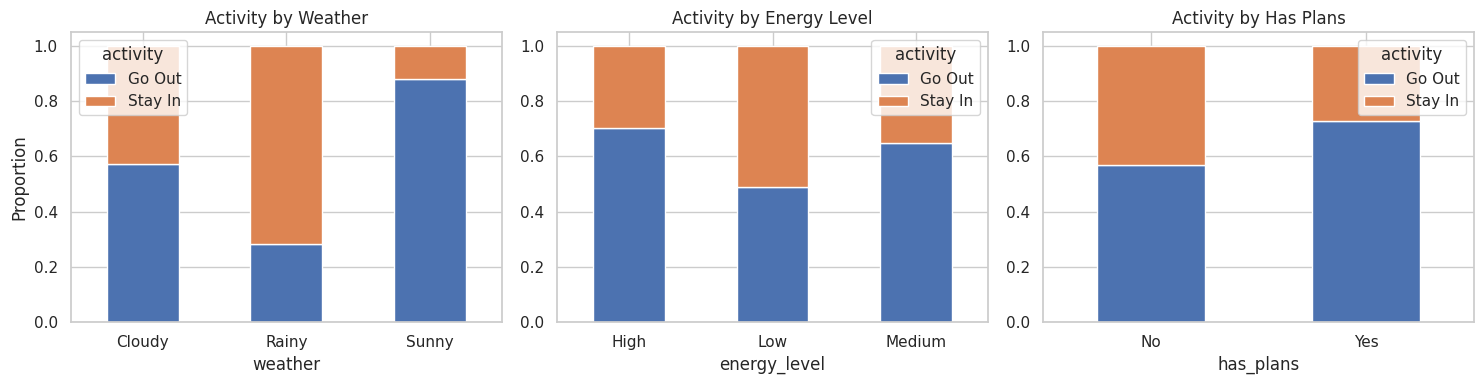

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ct.plot(kind="bar", stacked=True, ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Activity by Weather")
axes[0].set_ylabel("Proportion")
axes[0].tick_params(axis="x", rotation=0)

pd.crosstab(df["energy_level"], df["activity"], normalize="index") \
    .plot(kind="bar", stacked=True, ax=axes[1], color=["#4C72B0", "#DD8452"])
axes[1].set_title("Activity by Energy Level")
axes[1].tick_params(axis="x", rotation=0)

pd.crosstab(df["has_plans"], df["activity"], normalize="index") \
    .plot(kind="bar", stacked=True, ax=axes[2], color=["#4C72B0", "#DD8452"])
axes[2].set_title("Activity by Has Plans")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


## 3. Encode categorical features and fit a classification tree

All four predictors are categorical, so we one-hot encode them before fitting the tree
(scikit-learn's `DecisionTreeClassifier` requires numeric input).


In [5]:
feature_cols = ["weather", "energy_level", "is_weekday", "has_plans"]
X = df[feature_cols]
y = (df["activity"] == "Go Out").astype(int)   # 1 = Go Out, 0 = Stay In

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

encoder = OneHotEncoder(drop=None)
preprocess = ColumnTransformer([("cat", encoder, feature_cols)])

tree_clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("tree", DecisionTreeClassifier(criterion="gini", max_depth=4,
                                     min_samples_leaf=10, random_state=RANDOM_STATE))
])
tree_clf.fit(X_train, y_train)

y_pred = tree_clf.predict(X_test)
print("Test accuracy:", round(accuracy_score(y_test, y_pred), 3))
print()
print(classification_report(y_test, y_pred, target_names=["Stay In", "Go Out"]))


Test accuracy: 0.73

              precision    recall  f1-score   support

     Stay In       0.67      0.58      0.62        38
      Go Out       0.76      0.82      0.79        62

    accuracy                           0.73       100
   macro avg       0.71      0.70      0.71       100
weighted avg       0.73      0.73      0.73       100



In [6]:
feature_names = tree_clf.named_steps["preprocess"].get_feature_names_out()
print(export_text(tree_clf.named_steps["tree"], feature_names=list(feature_names)))


|--- cat__weather_Sunny <= 0.50
|   |--- cat__energy_level_Low <= 0.50
|   |   |--- cat__weather_Cloudy <= 0.50
|   |   |   |--- cat__is_weekday_No <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- cat__is_weekday_No >  0.50
|   |   |   |   |--- class: 1
|   |   |--- cat__weather_Cloudy >  0.50
|   |   |   |--- cat__has_plans_Yes <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- cat__has_plans_Yes >  0.50
|   |   |   |   |--- class: 1
|   |--- cat__energy_level_Low >  0.50
|   |   |--- cat__has_plans_No <= 0.50
|   |   |   |--- class: 0
|   |   |--- cat__has_plans_No >  0.50
|   |   |   |--- cat__weather_Cloudy <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- cat__weather_Cloudy >  0.50
|   |   |   |   |--- class: 0
|--- cat__weather_Sunny >  0.50
|   |--- cat__energy_level_Low <= 0.50
|   |   |--- cat__has_plans_Yes <= 0.50
|   |   |   |--- cat__energy_level_Medium <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- cat__energy_level_Medium >  0.50
|   |   |   |   |

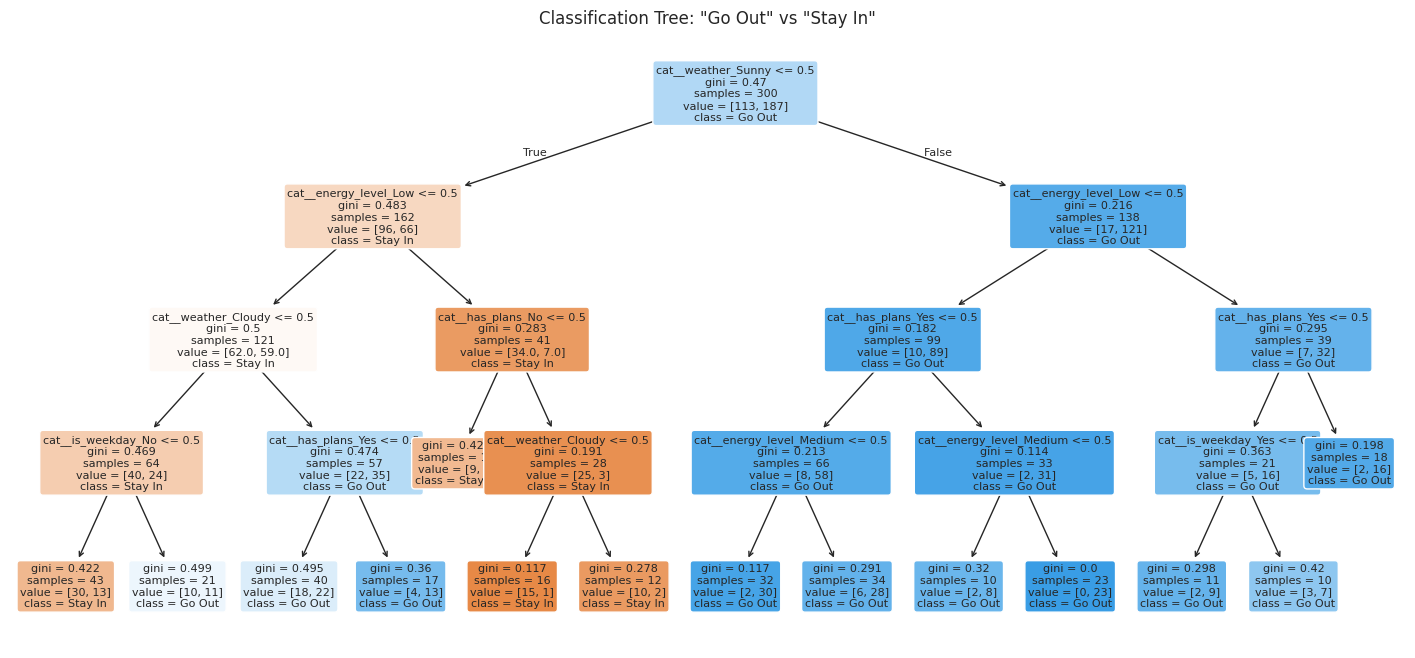

In [7]:
plt.figure(figsize=(18, 8))
plot_tree(tree_clf.named_steps["tree"], feature_names=feature_names,
          class_names=["Stay In", "Go Out"], filled=True, rounded=True, fontsize=8)
plt.title('Classification Tree: "Go Out" vs "Stay In"')
plt.show()


## 4. Confusion matrix and feature importance

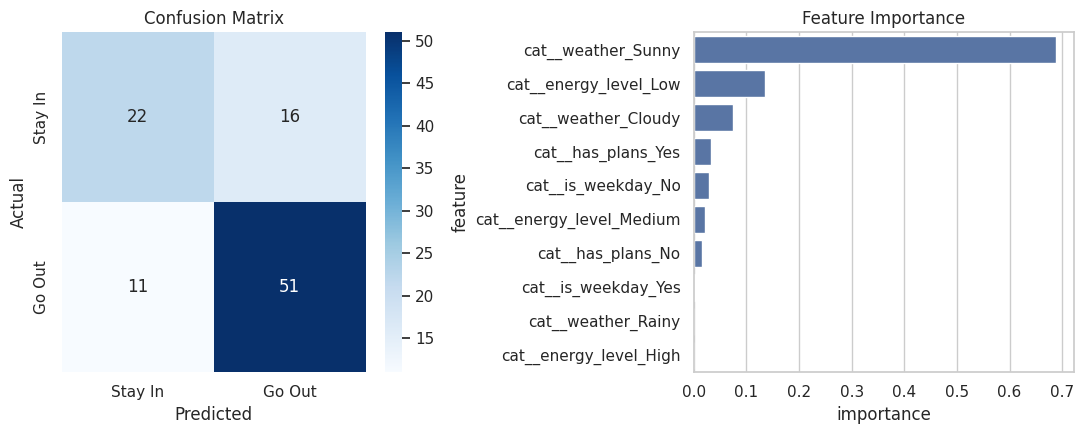

,feature,importance
2,cat__weather_Sunny,0.687990
4,cat__energy_level_Low,0.136055
0,cat__weather_Cloudy,0.075296
9,cat__has_plans_Yes,0.032977
6,cat__is_weekday_No,0.029001
5,cat__energy_level_Medium,0.020653
8,cat__has_plans_No,0.014962
7,cat__is_weekday_Yes,0.003065
1,cat__weather_Rainy,0.000000
3,cat__energy_level_High,0.000000


In [8]:
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Stay In", "Go Out"], yticklabels=["Stay In", "Go Out"], ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion Matrix")

imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": tree_clf.named_steps["tree"].feature_importances_
}).sort_values("importance", ascending=False)

sns.barplot(data=imp_df, x="importance", y="feature", ax=axes[1], color="#4C72B0")
axes[1].set_title("Feature Importance")

plt.tight_layout()
plt.show()

imp_df


As expected from the scenario, **weather** (particularly *Sunny* vs *Rainy*) dominates the
root of the tree and carries the most importance, since it's the single strongest predictor of
whether you go out or stay in — the other factors (energy level, weekday, existing plans) refine
the prediction further down the tree, similar to how `income` refined the `age` split in Exercise 1.


## 5. Predict today's likely activity

In [9]:
today = pd.DataFrame({
    "weather": ["Sunny"],
    "energy_level": ["Medium"],
    "is_weekday": ["Yes"],
    "has_plans": ["Yes"],
})

pred = tree_clf.predict(today)[0]
proba = tree_clf.predict_proba(today)[0]

print(f"Prediction: {'Go Out' if pred == 1 else 'Stay In'}")
print(f"P(Stay In)={proba[0]:.1%}   P(Go Out)={proba[1]:.1%}")


Prediction: Go Out
P(Stay In)=0.0%   P(Go Out)=100.0%
